# TMA4212 - Project 1
## by Mikail Mutu, Venuga Sivarajah, Trond Elias Ødegård

In [3]:
# Necessary libraries and useful parameters
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
newparams = {'axes.grid': True, 'axes.labelsize': 22,
             'xtick.labelsize': 18, 'ytick.labelsize': 18,
             'legend.fontsize': 18, 'axes.titlesize': 20}
plt.rcParams.update(newparams)
%matplotlib inline

In [4]:
# A 2D plot-maker
def plot_2D(X, Y, T, title, cmap='coolwarm', label='Temperature $T$'):
    fig, ax = plt.subplots()
    plt.title(title)
    heatmap = ax.pcolormesh(X, Y, T, cmap=cmap)
    plt.colorbar(heatmap, shrink=0.5, aspect=4, label=label)
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.show()

In [5]:
# Global model parameters
a = 1
r1 = 1
r2 = np.sqrt(2)
domain = [[0, 1], [0, 1]]

***Problem 1a***

In [6]:
def boundary_vector(BC, MN, HK, x, y):
  ''' 
  Creation of the boundary vector g for the heat distribution scheme.
  Input:
      BC: boundary functions [g1, g2, g3, g4]
      MN: number of grid points in each direction [M, N]
      HK: factors H=a/h**2 and K=1/k**2 [H, K] 
    x, y: discretized grids in x- and y-directions
  Output:
       g: boundary vector
  '''
  g1, g2, g3, g4 = BC
  M, N = MN
  H, K = HK
      
  # Construct a matrix containing boundary contributions.
  G = np.zeros((N-1, M-1))
  G[:, 0] += H * g1(x[0], y[1:N]) + K * g1(x[0], y[0:N-1])
  G[0, 1:] += K * g2(x[1:M-1], y[0])
  G[:, -1] += K * g3(x[-1], y[2:N+1]) + H * g3(x[-1], y[1:N])
  G[-1, :-1] += K * g4(x[2:M], y[-1])

  g = G.flatten()
  return g

In [7]:
def coeff_matrix(MN, HK):
    ''' 
    Creation of the coefficient matrix A for the heat distribution scheme.
    Input:
        MN: number of steps in x- and y-directions [M, N]
        HK: factors H=a/h**2 and K=1/k**2 [H, K] 
    Output:
        A: the coefficient matrix
    '''
    M, N = MN
    H, K = HK
    Z = (M-1)*(N-1)
    
    d1 = np.full(Z, -2*(H + K)) # The diagonal with -2(a/h^2+1/k^2)'s
    d2 = np.full(Z, H)          # The diagonals with a/h^2's
    d3 = np.full(Z, K)          # The diagonals with 1/k^2's

    d2[M-2::M-1], d3[M-2::M-1] = 0, 0 # Every M-1'th element is zero for d2 and d3
    
    A = sp.diags([d3, d2, d1, d2, d3], [-M, -1, 0, 1, M], (Z, Z), format='csc')
    
    return A

The following function $\texttt{heat}$ _ $\texttt{scheme()}$ is constructed to also work for the cases where $h\ne k$ and simple boundary fattening.

In [8]:
def heat_scheme(f, BC, MN, xy=domain, r=r1, N_fat=0):
      ''' 
      Solve the anisotropic heat distribution problem −∇·(κ∇T) = f
      Input:
                f: right hand side function
               BC: boundary conditions [g1, g2, g3, g4]
               MN: number of grid points for each direction [M, N]
               xy: the domain [[xi, xf], [yi, yf]]
            N_fat: extra rows added for boundary fattening (N_fat=0 is no fattening)
      Output:
                T: Numerical approximation to T(x,y)
             x, y: discretized grids in each direction
             X, Y: meshed grid
      '''
      g1, g2, g3, g4 = BC
      M, N = MN
      N += N_fat

      xi, xf = xy[0]
      yi, yf = xy[1]

      h = (xf-xi)/M
      k = np.abs(r)*h
      H, K = a/h**2, 1/k**2 # Used to construct A and g

      yf = k*N
      x = np.linspace(xi, xf, M+1)
      y = np.linspace(yi, yf, N+1)
      X, Y = np.meshgrid(x, y)

      A = coeff_matrix([M, N], [H, K])
      g = boundary_vector(BC, [M, N], [H, K], x, y) 
      
      T = np.zeros((N+1, M+1))
      T[:, 0] = g1(x[0], y)   # Left boundary
      T[0, :] = g2(x, y[0])   # Bottom boundary
      T[:, -1] = g3(x[-1], y) # Right boundary
      T[-1, :] = g4(x, y[-1]) # Top boundary
      
      T_interior = sp.linalg.spsolve(A, -(g + f(X, Y)[1:-1, 1:-1].flatten()))
      T[1:-1, 1:-1] = np.reshape(T_interior, (N-1, M-1))

      return T, x, y, X, Y

In [9]:
def t(x, y): # Exact solution
    return x*y

def f(x, y): # Right hand side
    return -2*r1*np.ones_like(x)

# Boundary conditions
def g1(x, y):
    return t(x, y)
def g2(x, y):
    return t(x, y)
def g3(x, y):
    return t(x, y)
def g4(x, y):
    return t(x, y)

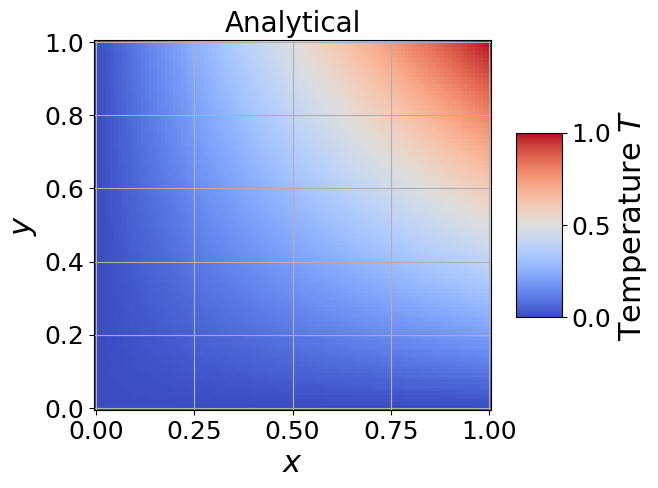

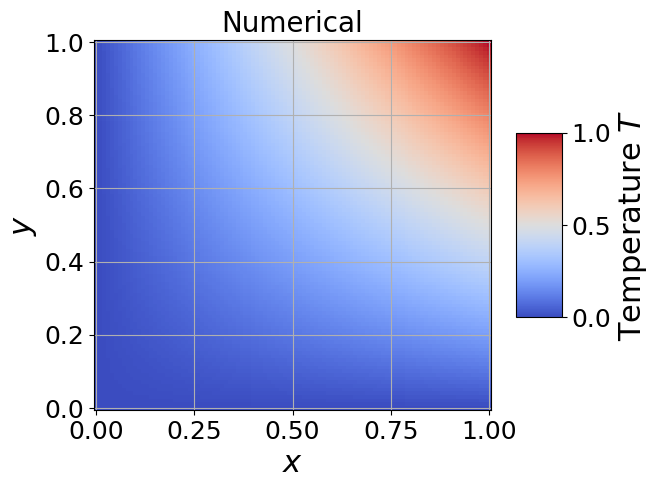

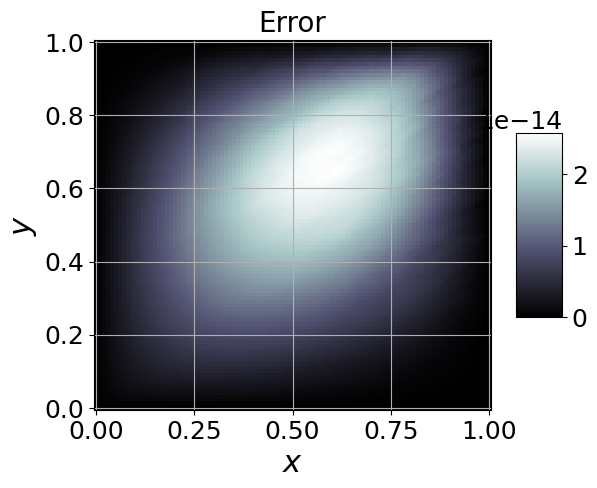

In [10]:
# Plots of numerical solution, analytical solution and the error
M = 100
T, x, y, X, Y = heat_scheme(f, [g1, g2, g3, g4], [M, M])

plot_2D(X, Y, t(X, Y), 'Analytical')
plot_2D(X, Y, T, 'Numerical')
plot_2D(X, Y, np.abs(T-t(X, Y)), 'Error', cmap='bone', label='')

***Problem 1c***

In [11]:
# Another test example.
def t(x, y):
    return np.sin(np.pi*x) + np.cos(y)

def f(x, y):
    return (a+1)*np.pi**2 * np.sin(np.pi*x) + r1**2 * np.cos(y)

def g1(x, y):
    return t(x, y)
def g2(x, y):
    return t(x, y)
def g3(x, y):
    return t(x, y)
def g4(x, y):
    return t(x, y)

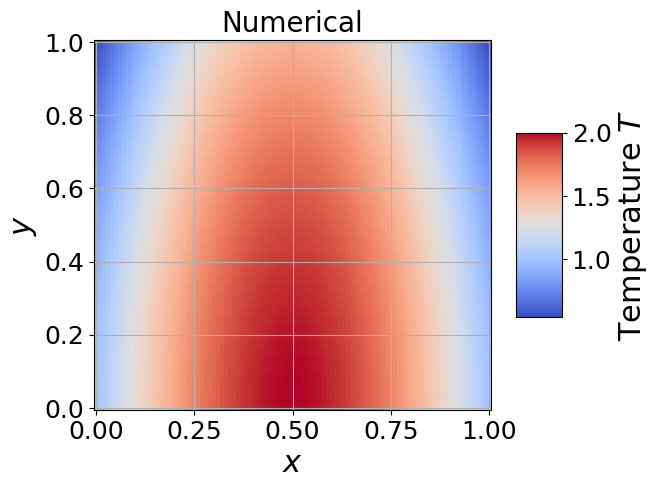

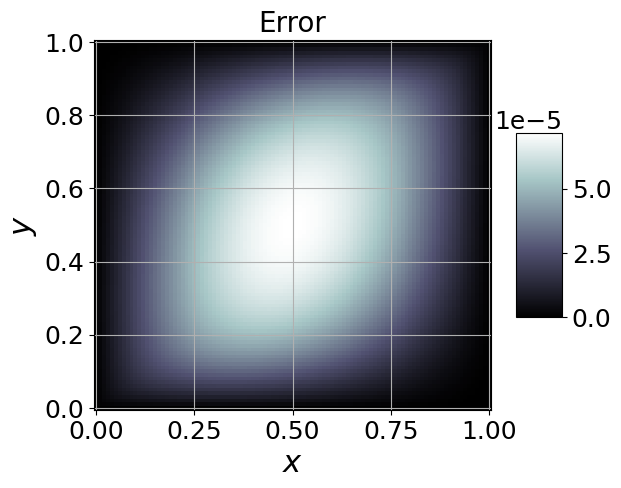

In [12]:
# Plots of numerical solution and the error.
M = 100
T, x, y, X, Y = heat_scheme(f, [g1, g2, g3, g4], [M, M])

plot_2D(X, Y, T, 'Numerical')
plot_2D(X, Y, np.abs(T-t(X, Y)), 'Error', cmap='bone', label='')

In [13]:
# Function operating a convergence study in infinity norm.
def convergence(t, M=[7,13,25,49,97,193], N=[7,13,25,49,97,193], solver=heat_scheme):
    d = len(M)
    H = np.zeros(d)
    Emax = np.zeros(d)
    
    for i in range(d):
        T, x, y, X, Y = solver(f, [g1, g2, g3, g4], [M[i], N[i]])
        Emax[i] = np.max(np.abs(T - t(X, Y)))
        H[i] = x[1]-x[0]
        
    p = np.polyfit(np.log(H), np.log(Emax), 1)[0]
    
    return H, Emax, p

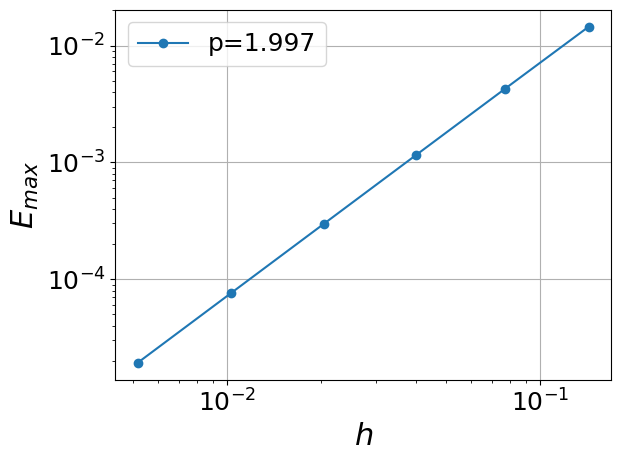

h =
['1.429e-01', '7.692e-02', '4.000e-02', '2.041e-02', '1.031e-02', '5.181e-03']
E_max(h) =
['1.449e-02', '4.234e-03', '1.148e-03', '2.990e-04', '7.632e-05', '1.928e-05']
p(h) =
[1.988, 1.992, 1.997, 1.999, 2.0, 2.0]


In [14]:
# Plot of the convergence.
H, E, p = convergence(t)

plt.figure()
plt.loglog(H, E, 'o-', label='p={:.3f}'.format(p))
plt.xlabel('$h$')
plt.ylabel('$E_{max}$')
plt.legend()
plt.show()

# Write out for making table of errors and convergence rates.
P = np.gradient(np.log(E), np.log(H)) # Convergence rate for each h

print('h =')
print([format(h, '.3e') for h in H])
print('E_max(h) =')
print([format(e, '.3e') for e in E])
print('p(h) =')
print([round(p, 3) for p in P])

***Problem 1d***

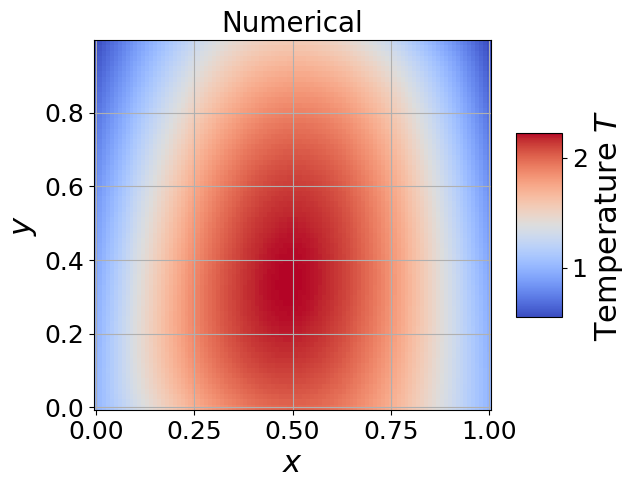

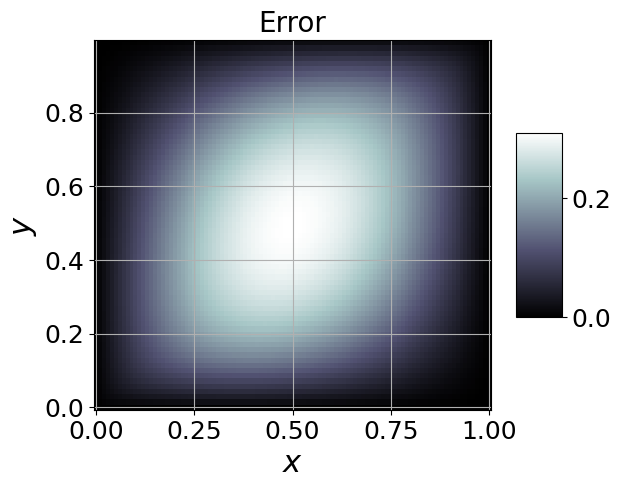

In [15]:
# Testing with irrational r (h and k are different), and 1 extra fattened row.
def f(x, y):
    return (a+1)*np.pi**2 * np.sin(np.pi*x) + r2**2 * np.cos(y)

M = 100
N, N_f = int(M/np.abs(r2)), 1
T, x, y, X, Y = heat_scheme(f, [g1, g2, g3, g4], [M, N], r=r2, N_fat=N_f)

plot_2D(X[:-N_f], Y[:-N_f], T[:-N_f], 'Numerical')
plot_2D(X[:-N_f], Y[:-N_f], np.abs(T[:-N_f]-t(X[:-N_f], Y[:-N_f])), 'Error', cmap='bone', label='')

In [16]:
# Convergence function for the boundary affected by fattening.
def convergence_bnd(t, M, N, solver=heat_scheme):
    d = len(M)
    H = np.zeros(d)
    Emax = np.zeros(d)
    
    for i in range(d):
        T, x, y, X, Y = solver(f, [g1, g2, g3, g4], [M[i], N[i]], r=r2, N_fat=N_f)
        Emax[i] = np.max(np.abs(T[-N_f-1] - t(X[-N_f-1], Y[-N_f-1])))
        H[i] = x[1]-x[0]
        
    p = np.polyfit(np.log(H), np.log(Emax), 1)[0]
    
    return H, Emax, p

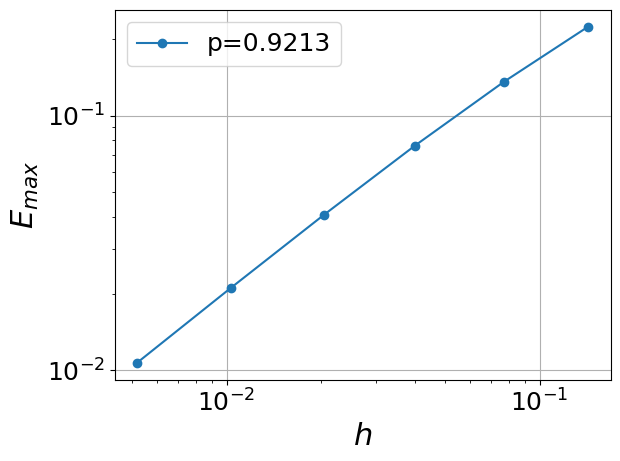

In [17]:
M=[7,13,25,49,97,193]
N = [int(i/np.abs(r2)) for i in M]

# Plot of the convergence.
H, E, p = convergence_bnd(t, M, N)

plt.figure()
plt.loglog(H, E, 'o-', label='p={:.4f}'.format(p))
plt.xlabel('$h$')
plt.ylabel('$E_{max}$')
plt.legend()
plt.show()

***Problem 2***

### Modified discretization

### Fattening the boundary

IGNORE TASK 2 (NOT COMPLETED)